# Temporal analysis of Fake News/Politically Charged links


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import powerlaw


In [2]:
# Load the datasets
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

## Extract politically charged messages


In [3]:
# Check possible values for fake_information column in df_links
print(df_links['fake_information'].unique())

<StringArray>
[             nan,        'unknown',           'high',          'Mixed',
            'low',           'True', 'mostly factual',      'very high',
          'mixed',       'very-low']
Length: 10, dtype: str


In [4]:
# Gather the messages with misinformation
misinformation_levels = ['Mixed', 'low', 'True', 'mixed', 'very-low']
# Gather messages with those values in the "fake information" column
misinformation_messages = df_links[df_links['fake_information'].isin(misinformation_levels)]
# Gather messages with "high" or "very-high" misinformation score
informative_messages = df_links[df_links['fake_information'].isin(['high', 'very high', np.nan])] # idk if I should add nan values, but I will do it just in case



In [5]:

misinformation_messages.head()

,date,links,platform,username,sender_id,sender_username,sender_name,sender_type,count,username_count,political,type,political_orientation,fake_information,is_forwarded,fwd_from_channel_id,fwd_from_channel_name
103,2024-11-02T07:49:30+00:00,https://x.com/okdiario/status/1852342806922043...,twitter,okdiario,702737014,semillavf,VF,user,1.0,7.0,political,extracted_link,far-right,Mixed,NaN,NaN,NaN
106,2024-11-02T08:53:47+00:00,https://gaceta.es/espana/mazon-y-marlaska-pide...,other,gaceta,524281487,SocialPermanent,: Vic.,user,1.0,2.0,political,extracted_link,far-right,low,NaN,NaN,NaN
108,2024-11-02T10:15:06+00:00,https://t.me/rubengisbertoficial/2008,telegram,rubengisbertoficial,1696509502,Bordallin,Irene,user,1.0,10.0,NaN,extracted_link,anti-establisment,True,NaN,NaN,NaN
119,2024-11-02T12:27:53+00:00,https://www.larazon.es/sociedad/acertada-predi...,other,larazon,7046448,nbseks,diana,user,1.0,4.0,political,extracted_link,right,Mixed,NaN,NaN,NaN
139,2024-11-02T16:33:21+00:00,https://cnnespanol.cnn.com/2024/11/01/inundaci...,other,cnn,7094531229,NaN,CarlosM,user,2.0,2.0,political,extracted_link,center-left,Mixed,NaN,NaN,NaN


In [6]:
df.head()

,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",NaN,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",NaN,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,NaN,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [7]:
import pandas as pd

# Work on copies to avoid mutating original dataframes
mis = misinformation_messages.copy()
full = df.copy()

# 1) Normalize sender_id type
mis["sender_id"] = pd.to_numeric(mis["sender_id"], errors="coerce").astype("Int64")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
mis["date_dt"] = pd.to_datetime(mis["date"], utc=True, errors="coerce")
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")


# 3) Exact match on sender_id + date
matches = mis.merge(
    full,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_misinfo", "_df")
)

# 4) Found vs not found (df has column `id`)
found = matches[matches["id"].notna()]
not_found = matches[matches["id"].isna()]

print("Found:", len(found))
print("Not found:", len(not_found))

# Preview matched rows
found[["date_dt", "sender_id", "links", "id"]].head()

Found: 182
Not found: 0


,date_dt,sender_id,links,id
0,2024-11-02 07:49:30+00:00,702737014,https://x.com/okdiario/status/1852342806922043...,8361
1,2024-11-02 08:53:47+00:00,524281487,https://gaceta.es/espana/mazon-y-marlaska-pide...,8556
2,2024-11-02 10:15:06+00:00,1696509502,https://t.me/rubengisbertoficial/2008,8925
3,2024-11-02 12:27:53+00:00,7046448,https://www.larazon.es/sociedad/acertada-predi...,9660
4,2024-11-02 16:33:21+00:00,7094531229,https://cnnespanol.cnn.com/2024/11/01/inundaci...,11195


## Temporal analysis of messages one hour after misinformation link

Number of waiting times: 1411
Min/median/max waiting time (secs): 1.0 1559.0 3591.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


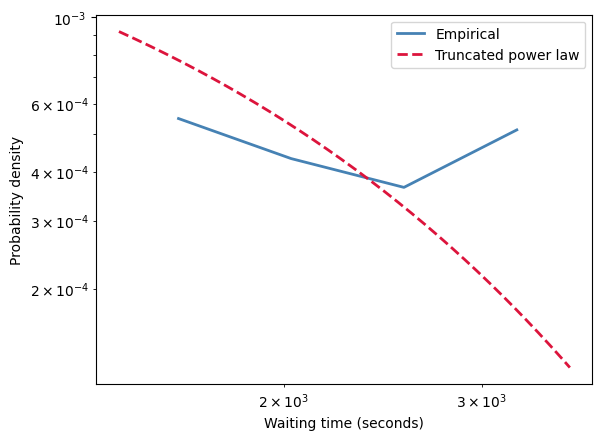

Fitted truncated power law:


In [8]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full dataset with parsed timestamps
full = df.copy()
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full["topic_name"].eq(source["topic_name"])
    within_window = full["date_dt"].gt(source["date_dt"]) & full["date_dt"].le(source["date_dt"] + window)

    later_messages = full.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

Number of waiting times: 1411
Min/median/max waiting time (secs): 1.0 1559.0 3591.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


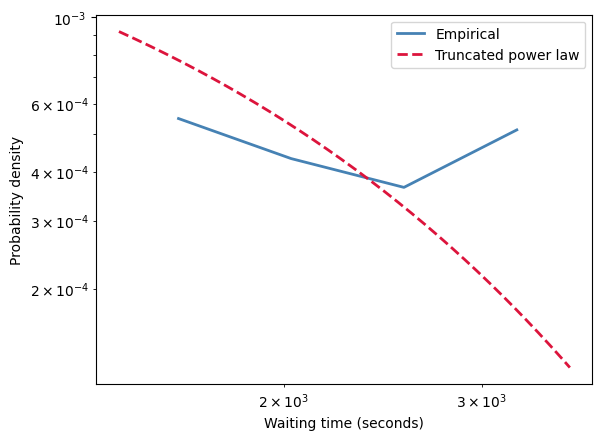

Fitted truncated power law:


In [9]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full dataset with parsed timestamps
full = df.copy()
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")
full = full.dropna(subset=["date_dt", "topic_name"])

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full["topic_name"].eq(source["topic_name"])
    within_window = full["date_dt"].gt(source["date_dt"]) & full["date_dt"].le(source["date_dt"] + window)

    later_messages = full.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

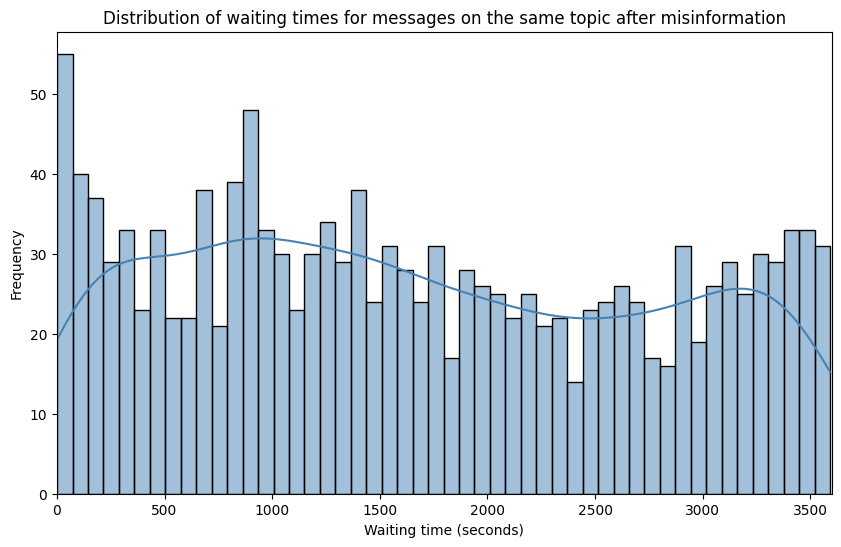

In [10]:
# Obtain the distribution of waiting times
waiting_times = waiting_times_df["wait_seconds"].to_numpy()
waiting_times = waiting_times[waiting_times > 0]
# Plot the distribution of waiting times
plt.figure(figsize=(10, 6))
sns.histplot(waiting_times, bins=50, kde=True, color="steelblue")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of waiting times for messages on the same topic after misinformation")
plt.xlim(0, 3600)  # Limit x-axis to 1 hour
plt.show()


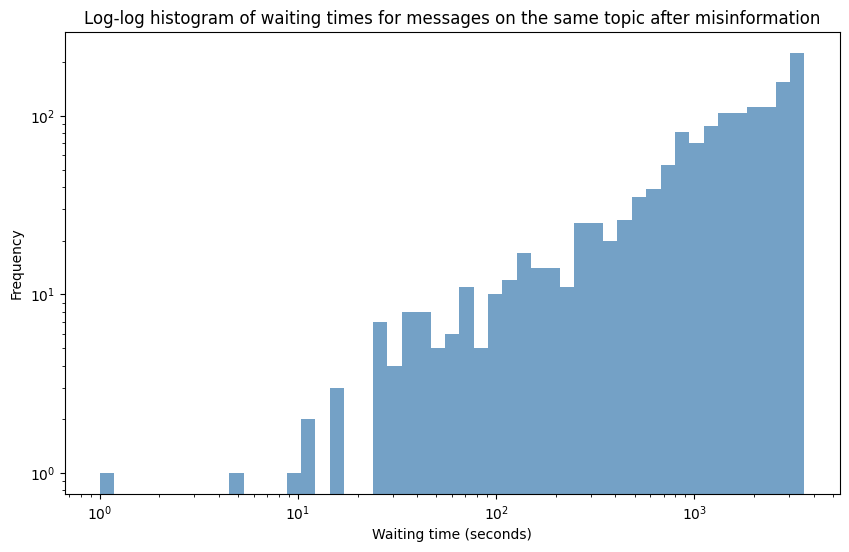

In [11]:
# histogram of waiting times with log-log scale and logarithmic bins
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(waiting_times.min()), np.log10(waiting_times.max()), 50)
sns.histplot(waiting_times, bins=bins, kde=False, color="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Log-log histogram of waiting times for messages on the same topic after misinformation")
plt.show()  

POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 2.8899
xmin: 1427.0000
sigma: 0.0680
Data points above xmin: 773 / 1411 (54.78%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -21.2538, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -11.2196, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -21.2341, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.1888
KS p-value (tail): 6.16307e-25


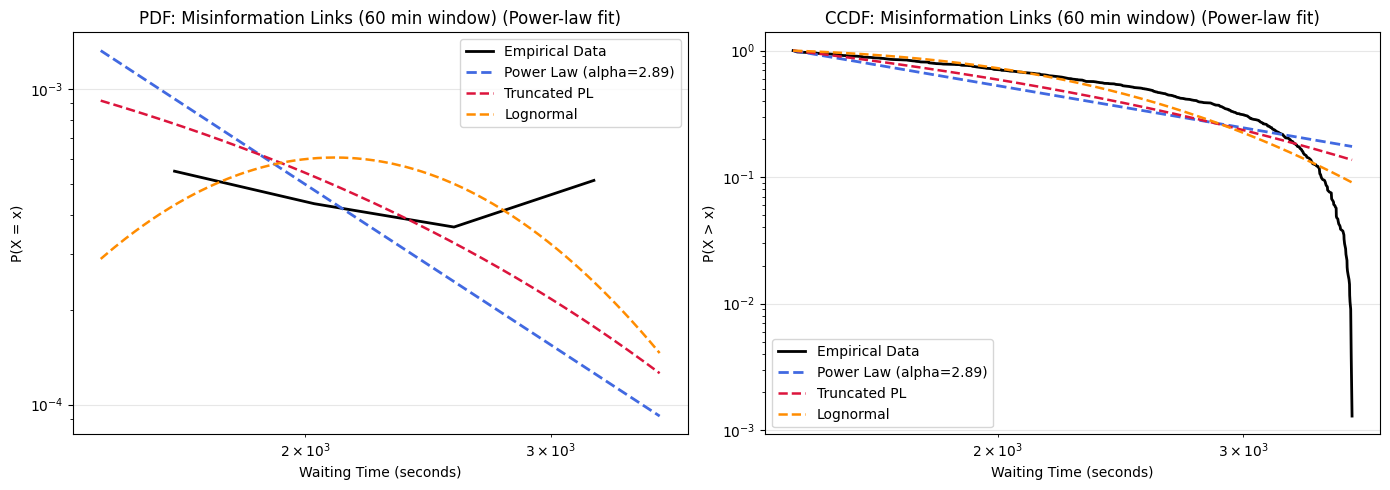

In [12]:
# Plain power-law fit for both groups
from scipy import stats

def fit_power_law_report(waiting_times_input, label, discrete=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    print("=" * 70)
    print(f"POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_pl:.4f}")
    print(f"xmin: {xmin_pl:.4f}")
    print(f"sigma: {sigma_pl:.4f}")
    n_tail_pl = int(np.sum(data_pl >= xmin_pl))
    print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

    print("\n" + "=" * 70)
    print("POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
        ("power_law", "lognormal", "Power Law vs Lognormal"),
        ("power_law", "exponential", "Power Law vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        ks_stat_pl, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (power law): {ks_pl:.4f}")
    print(f"KS p-value (tail): {ks_p_pl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
    fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
    fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label} (Power-law fit)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
    fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
    fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label} (Power-law fit)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_pl


# Use the waiting times that were already computed above for misinformation
mis_waiting_times = waiting_times
fit_mis_pl = fit_power_law_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)

# Informative waiting times are built in the next section, where `found_inf` exists.
# Keeping this cell focused on the already-available misinformation series avoids the NameError.


## Temporal analysis of messages one hour after informative links

In [13]:
import pandas as pd

# Work on copies to avoid mutating original dataframes
inf = informative_messages.copy()
full_inf = df.copy()

# 1) Normalize sender_id type
inf["sender_id"] = pd.to_numeric(inf["sender_id"], errors="coerce").astype("Int64")
full_inf["sender_id"] = pd.to_numeric(full_inf["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
inf["date_dt"] = pd.to_datetime(inf["date"], utc=True, errors="coerce")
full_inf["date_dt"] = pd.to_datetime(full_inf["date"], utc=True, errors="coerce")


# 3) Exact match on sender_id + date
matches = inf.merge(
    full_inf,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_informative", "_df")
)

# 4) Found vs not found (df has column `id`)
found_inf = matches[matches["id"].notna()]
not_found_inf = matches[matches["id"].isna()]

print("Found:", len(found_inf))
print("Not found:", len(not_found_inf))

# Preview matched rows
found_inf[["date_dt", "sender_id", "links", "id"]].head()

Found: 1954
Not found: 7


,date_dt,sender_id,links,id
0,2024-10-30 15:00:42+00:00,1110241832,https://www.instagram.com/victimas_dana_vlc/pr...,47.0
1,2024-10-30 19:15:18+00:00,1110241832,https://www.google.com/maps/d/viewer?mid=1WbP4...,50.0
2,2024-10-30 19:58:22+00:00,1110241832,https://g.co/kgs/y7dLSiz,56.0
3,2024-10-30 19:59:30+00:00,1110241832,https://g.co/kgs/q6e1mmU,57.0
4,2024-10-30 20:00:34+00:00,1110241832,https://g.co/kgs/VDFK7XY,58.0


Number of waiting times: 12823
Min/median/max waiting time (secs): 1.0 1584.0 3600.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


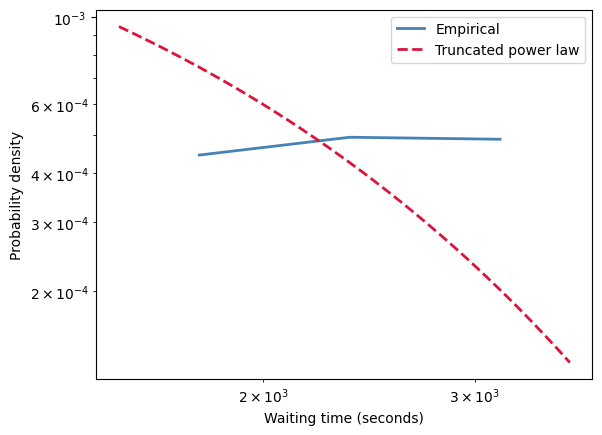

Fitted truncated power law:


In [14]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full informative dataset with parsed timestamps
full_inf = df.copy()
full_inf["date_dt"] = pd.to_datetime(full_inf["date"], utc=True, errors="coerce")
full_inf["sender_id"] = pd.to_numeric(full_inf["sender_id"], errors="coerce").astype("Int64")

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found_inf[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full_inf["topic_name"].eq(source["topic_name"])
    within_window = full_inf["date_dt"].gt(source["date_dt"]) & full_inf["date_dt"].le(source["date_dt"] + window)

    later_messages = full_inf.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

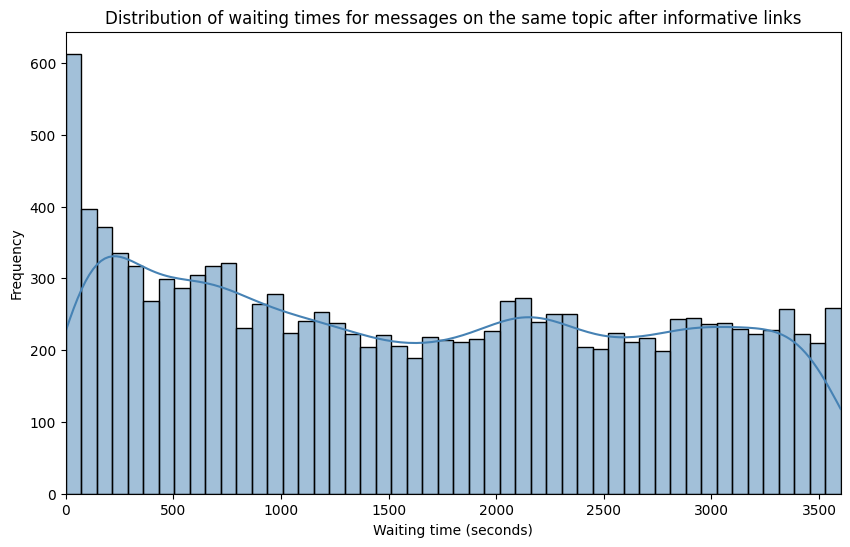

In [15]:
# Obtain the distribution of waiting times
waiting_times = waiting_times_df["wait_seconds"].to_numpy()
waiting_times = waiting_times[waiting_times > 0]
# Plot the distribution of waiting times
plt.figure(figsize=(10, 6))
sns.histplot(waiting_times, bins=50, kde=True, color="steelblue")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of waiting times for messages on the same topic after informative links")
plt.xlim(0, 3600)  # Limit x-axis to 1 hour
plt.show()


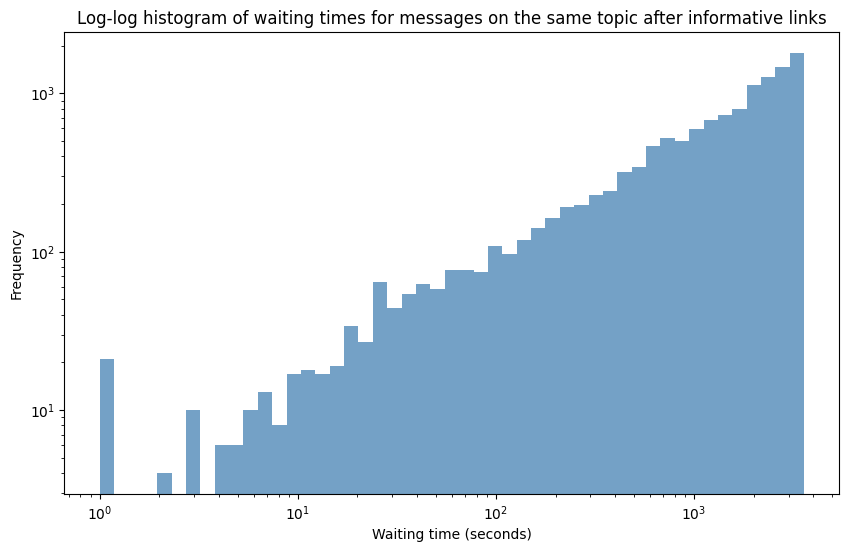

In [16]:
# histogram of waiting times with log-log scale and logarithmic bins
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(waiting_times.min()), np.log10(waiting_times.max()), 50)
sns.histplot(waiting_times, bins=bins, kde=False, color="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Log-log histogram of waiting times for messages on the same topic after informative links")
plt.show()  

Misinformation waiting times: 1411
Informative waiting times: 12823


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 0.0000
lambda: 0.000919
xmin: 1427.0000
sigma: nan
Data points above xmin: 773 / 1411 (54.78%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 21.2538, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -6.0560, p = 0.0000
  lognormal is significantly better

Truncated PL vs Exponential:
  R = -0.0289, p = 0.9769
  No significant difference

KS distance (truncated power law): 0.1456
KS p-value (tail): 4.96612e-15


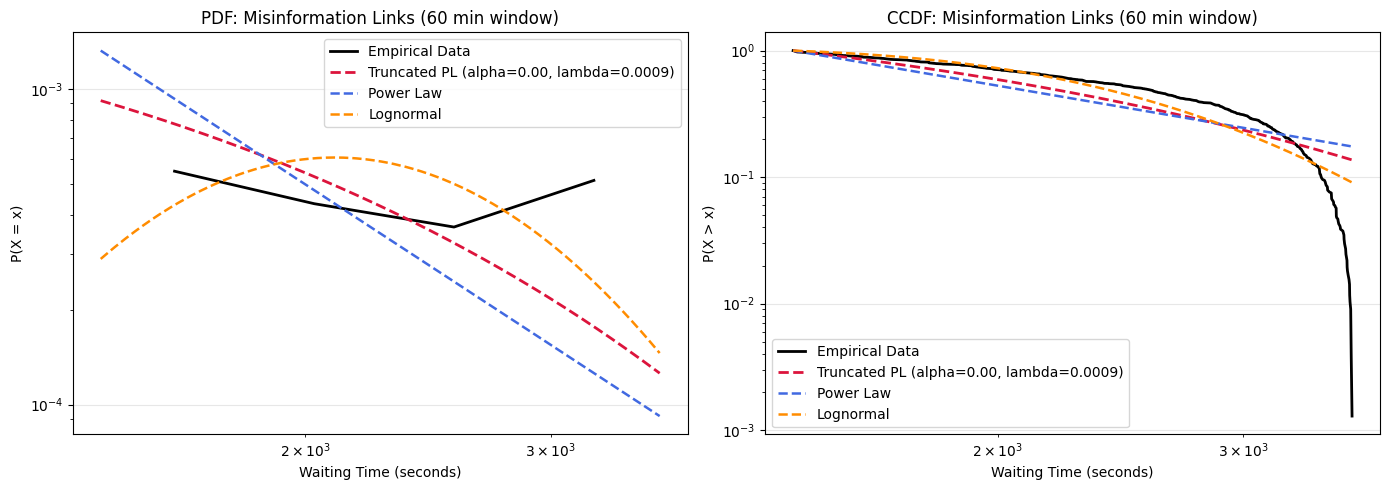

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; cons

TRUNCATED POWER LAW FIT RESULTS: Informative Links (60 min window)
alpha: 0.0000
lambda: 0.000947
xmin: 1516.0000
sigma: nan
Data points above xmin: 6605 / 12823 (51.51%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 78.5951, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -26.3418, p = 0.0000
  lognormal is significantly better

Truncated PL vs Exponential:
  R = -0.0022, p = 0.9983
  No significant difference

KS distance (truncated power law): 0.1576
KS p-value (tail): 4.17929e-144


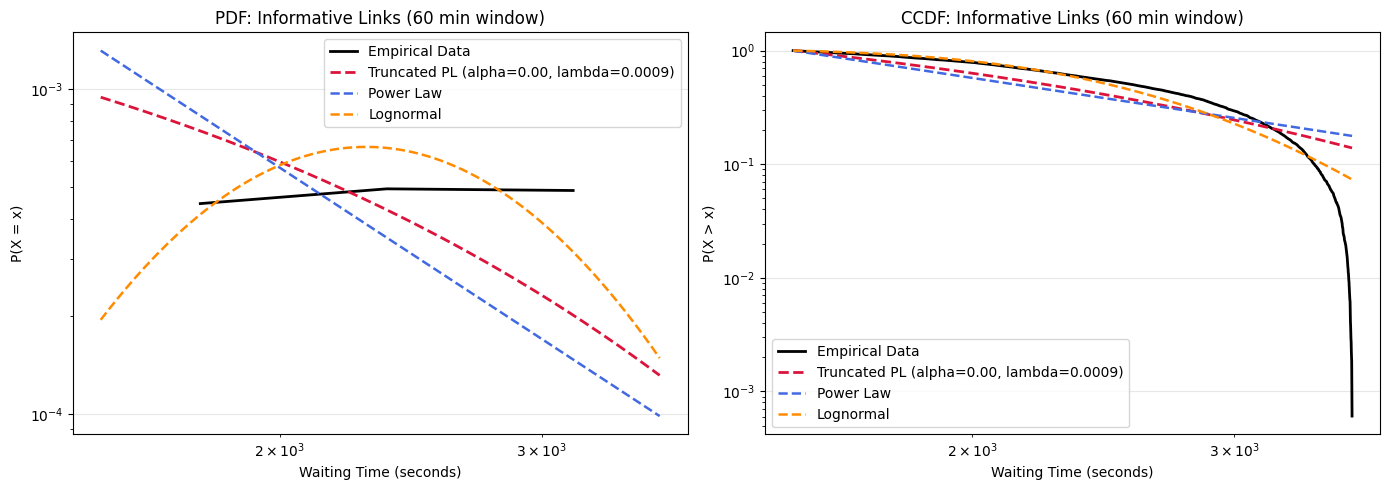

In [17]:
from scipy import stats


def collect_waiting_times_from_found(found_df, full_df, window_minutes=60):
    full_local = full_df.copy()
    full_local["date_dt"] = pd.to_datetime(full_local["date"], utc=True, errors="coerce")
    full_local["sender_id"] = pd.to_numeric(full_local["sender_id"], errors="coerce").astype("Int64")
    full_local = full_local.dropna(subset=["date_dt", "topic_name"])

    source_messages = (
        found_df[["id", "date_dt", "topic_name"]]
        .dropna(subset=["id", "date_dt", "topic_name"])
        .drop_duplicates(subset=["id"])
        .copy()
    )

    window = pd.Timedelta(minutes=window_minutes)
    waiting_times_records = []

    for _, source in source_messages.iterrows():
        same_topic = full_local["topic_name"].eq(source["topic_name"])
        within_window = full_local["date_dt"].gt(source["date_dt"]) & full_local["date_dt"].le(source["date_dt"] + window)

        later_messages = full_local.loc[
            same_topic & within_window,
            ["id", "date", "date_dt", "topic_name", "sender_id"]
        ].copy()

        if later_messages.empty:
            continue

        later_messages["source_id"] = source["id"]
        later_messages["source_date_dt"] = source["date_dt"]
        later_messages["wait_seconds"] = (later_messages["date_dt"] - source["date_dt"]).dt.total_seconds()
        waiting_times_records.append(later_messages)

    if not waiting_times_records:
        empty_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
        return empty_df, np.array([])

    waiting_times_df_local = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times_local = waiting_times_df_local["wait_seconds"].to_numpy(dtype=float)
    waiting_times_local = waiting_times_local[np.isfinite(waiting_times_local)]
    waiting_times_local = waiting_times_local[waiting_times_local > 0]

    return waiting_times_df_local, waiting_times_local


def fit_tpl_report(waiting_times_input, label, discrete=True):
    data_tpl = np.asarray(waiting_times_input, dtype=float)
    data_tpl = data_tpl[np.isfinite(data_tpl)]
    data_tpl = data_tpl[data_tpl > 0]

    if len(data_tpl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_tpl)}).")
        print("=" * 70)
        return None

    fit_tpl = powerlaw.Fit(data_tpl, discrete=discrete, verbose=False)
    tpl = fit_tpl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "Lambda", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)

    print("=" * 70)
    print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_tpl:.4f}")
    print(f"lambda: {lambda_tpl:.6f}")
    print(f"xmin: {xmin_tpl:.4f}")
    print(f"sigma: {sigma_tpl:.4f}")
    n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
    print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

    print("\n" + "=" * 70)
    print("TRUNCATED POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
        ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
        ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Truncated power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
    if len(tail_tpl) == 0:
        ks_tpl = float("nan")
        ks_p_tpl = float("nan")
    else:
        empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
        try:
            model_cdf_tpl = tpl.cdf(tail_tpl)
        except Exception:
            model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
        ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
        ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (truncated power law): {ks_tpl:.4f}")
    print(f"KS p-value (tail): {ks_p_tpl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_tpl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    tpl.plot_pdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[0]
    )
    fit_tpl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
    fit_tpl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_tpl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    tpl.plot_ccdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[1]
    )
    fit_tpl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
    fit_tpl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_tpl


# Build waiting times for misinformation and informative links
mis_waiting_df, mis_waiting_times = collect_waiting_times_from_found(found, df, window_minutes=60)
inf_waiting_df, inf_waiting_times = collect_waiting_times_from_found(found_inf, df, window_minutes=60)

print(f"Misinformation waiting times: {len(mis_waiting_times)}")
print(f"Informative waiting times: {len(inf_waiting_times)}")

# Fit both with the same procedure used in temporal_dist_channel
fit_mis = fit_tpl_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)
fit_inf = fit_tpl_report(inf_waiting_times, "Informative Links (60 min window)", discrete=True)

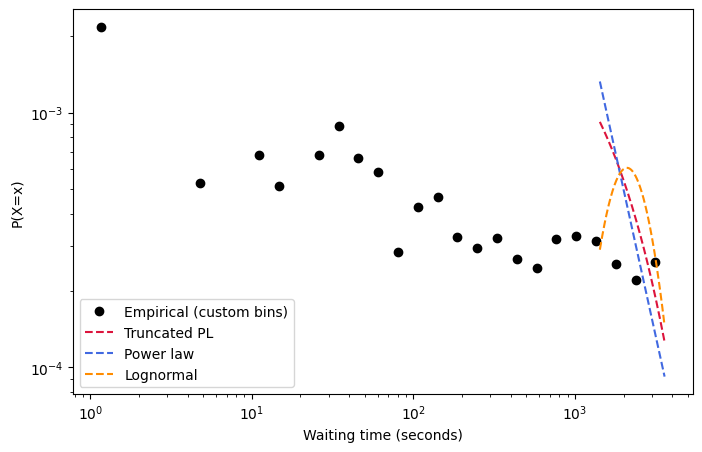

In [18]:
# Empirical PDF with custom bins (more points)
data = np.asarray(mis_waiting_times, dtype=float)
data = data[np.isfinite(data)]
data = data[data > 0]

bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)

plt.figure(figsize=(8,5))
powerlaw.plot_pdf(data, bins=bins, color="black", marker="o", linestyle="none", label="Empirical (custom bins)")
fit_mis.truncated_power_law.plot_pdf(color="crimson", linestyle="--", label="Truncated PL")
fit_mis.power_law.plot_pdf(color="royalblue", linestyle="--", label="Power law")
fit_mis.lognormal.plot_pdf(color="darkorange", linestyle="--", label="Lognormal")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("P(X=x)")
plt.legend()
plt.show()

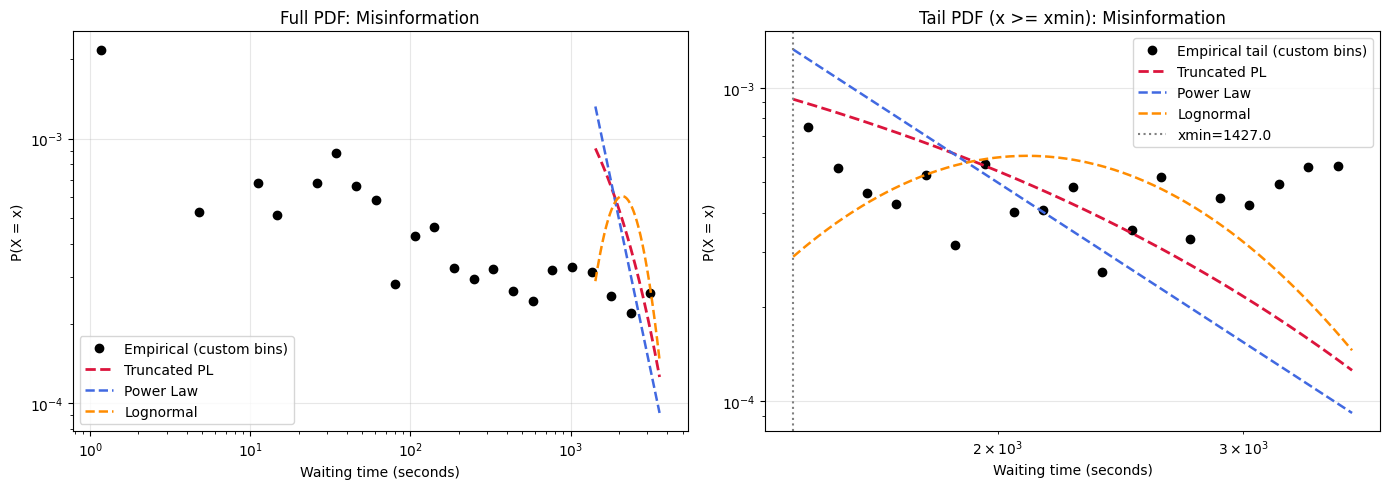

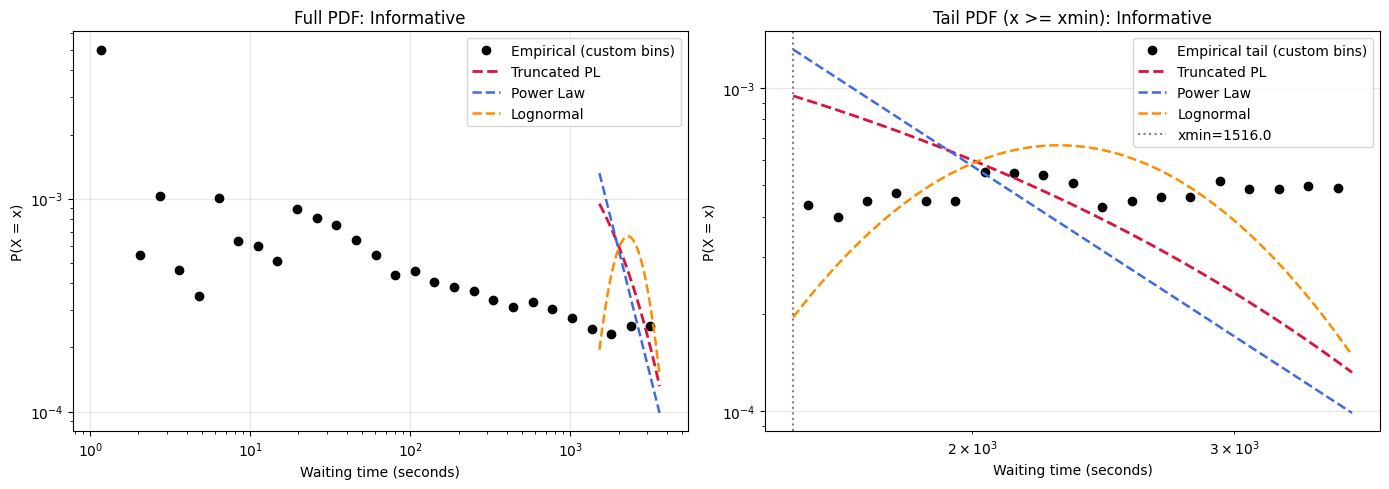

In [19]:
# Full-data vs tail-only PDF (custom bins) for both groups

def plot_full_vs_tail_pdf(data, fit_obj, label, n_bins_full=30, n_bins_tail=20):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    if len(data) < 2 or fit_obj is None:
        print(f"{label}: not enough data to plot.")
        return

    xmin = float(fit_obj.xmin)
    tail = data[data >= xmin]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: full data with custom bins
    bins_full = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins_full)
    powerlaw.plot_pdf(
        data, bins=bins_full, color="black", marker="o", linestyle="none",
        label="Empirical (custom bins)", ax=axes[0]
    )
    fit_obj.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=2, label="Truncated PL", ax=axes[0])
    fit_obj.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
    fit_obj.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Waiting time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"Full PDF: {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: tail only (x >= xmin) with custom bins
    if len(tail) >= 2 and tail.min() < tail.max():
        bins_tail = np.logspace(np.log10(tail.min()), np.log10(tail.max()), n_bins_tail)
        powerlaw.plot_pdf(
            tail, bins=bins_tail, color="black", marker="o", linestyle="none",
            label="Empirical tail (custom bins)", ax=axes[1]
        )
    else:
        axes[1].text(0.5, 0.5, "Not enough tail points", ha="center", va="center", transform=axes[1].transAxes)

    fit_obj.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=2, label="Truncated PL", ax=axes[1])
    fit_obj.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
    fit_obj.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].axvline(xmin, color="gray", linestyle=":", linewidth=1.5, label=f"xmin={xmin:.1f}")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Waiting time (seconds)")
    axes[1].set_ylabel("P(X = x)")
    axes[1].set_title(f"Tail PDF (x >= xmin): {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_full_vs_tail_pdf(mis_waiting_times, fit_mis, "Misinformation")
plot_full_vs_tail_pdf(inf_waiting_times, fit_inf, "Informative")

### Normal Power Law

POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 2.8899
xmin: 1427.0000
sigma: 0.0680
Data points above xmin: 773 / 1411 (54.78%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -21.2538, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -11.2196, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -21.2341, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.1888
KS p-value (tail): 6.16307e-25


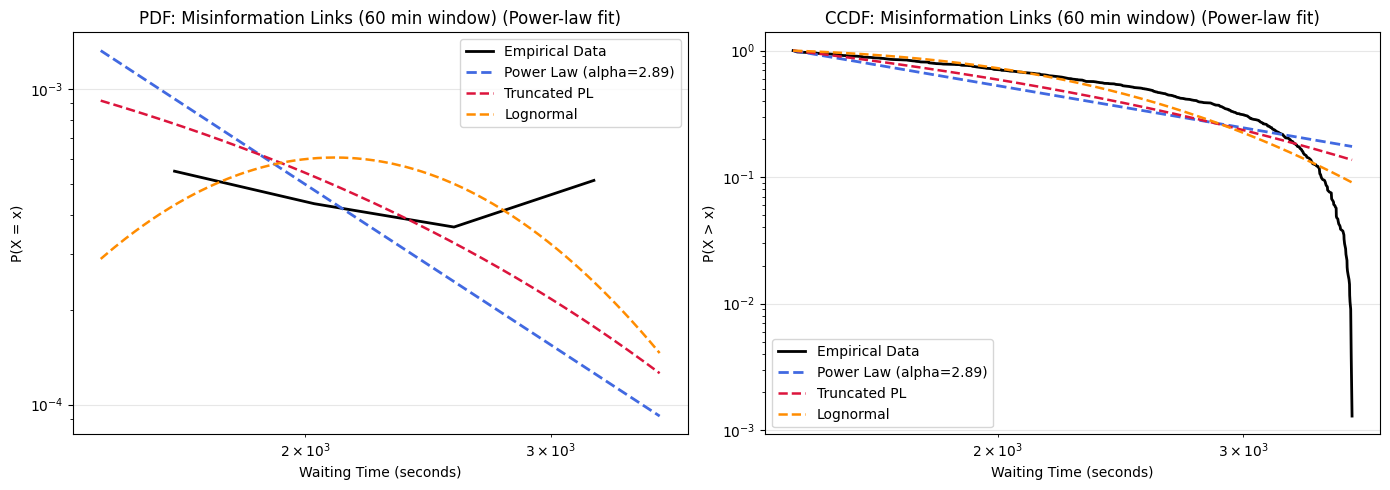

POWER LAW FIT RESULTS: Informative Links (60 min window)
alpha: 2.9991
xmin: 1516.0000
sigma: 0.0246
Data points above xmin: 6605 / 12823 (51.51%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; cons


Power Law vs Truncated PL:
  R = -78.5951, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -40.3226, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -78.5714, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.2140
KS p-value (tail): 2.94296e-266


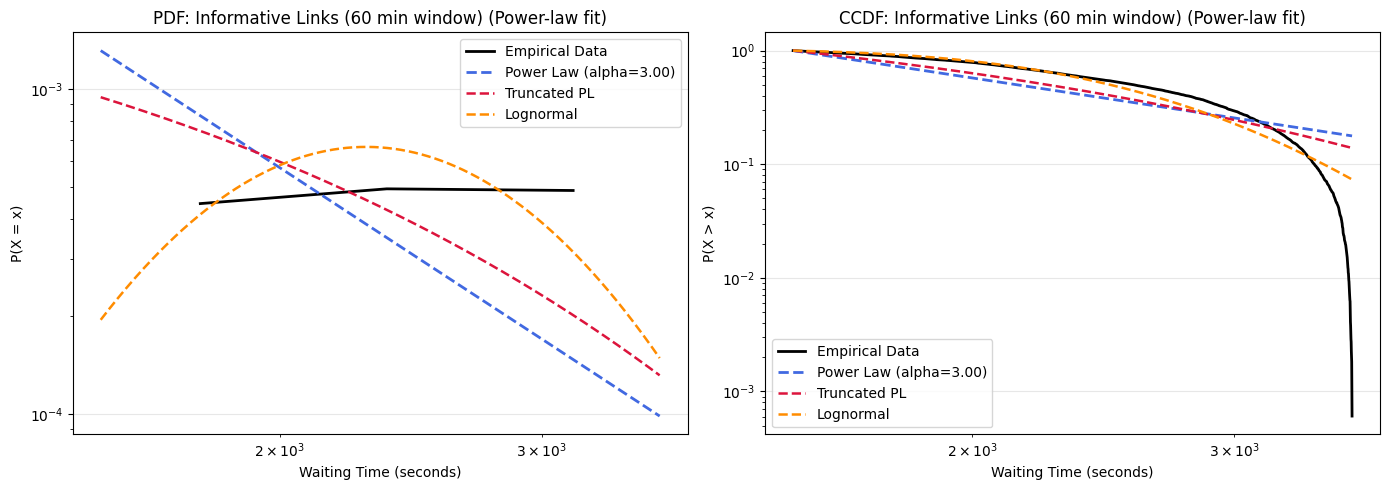

In [20]:
# Plain power-law fit for both groups

def fit_power_law_report(waiting_times_input, label, discrete=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    print("=" * 70)
    print(f"POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_pl:.4f}")
    print(f"xmin: {xmin_pl:.4f}")
    print(f"sigma: {sigma_pl:.4f}")
    n_tail_pl = int(np.sum(data_pl >= xmin_pl))
    print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

    print("\n" + "=" * 70)
    print("POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
        ("power_law", "lognormal", "Power Law vs Lognormal"),
        ("power_law", "exponential", "Power Law vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        ks_stat_pl, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (power law): {ks_pl:.4f}")
    print(f"KS p-value (tail): {ks_p_pl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
    fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
    fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label} (Power-law fit)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
    fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
    fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label} (Power-law fit)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_pl


fit_mis_pl = fit_power_law_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)
fit_inf_pl = fit_power_law_report(inf_waiting_times, "Informative Links (60 min window)", discrete=True)

## Temporal analysis of random messages one hour after

### Misinformative distribution

In [28]:
mis = misinformation_messages.copy()  # Make a copy to avoid modifying original
n_mis = len(mis)  # Number of misinformation messages

# Reshuffle sender_id within each topic when topic information is available.
# If the topic column is missing in `mis`, try to recover it from `df` using message id.
topic_candidates = ["topic_name", "topic", "topic_id", "topic_title"]
topic_col = next((c for c in topic_candidates if c in mis.columns), None)

if topic_col is None:
    topic_like_cols = [c for c in mis.columns if "topic" in str(c).lower()]
    topic_col = topic_like_cols[0] if topic_like_cols else None

if topic_col is None and "df" in globals() and "id" in mis.columns:
    if {"id", "topic_name"}.issubset(df.columns):
        topic_lookup = df[["id", "topic_name"]].dropna().drop_duplicates(subset=["id"])
        mis = mis.merge(topic_lookup, on="id", how="left", suffixes=("", "_from_df"))
        if "topic_name" in mis.columns:
            topic_col = "topic_name"
        elif "topic_name_from_df" in mis.columns:
            topic_col = "topic_name_from_df"

if topic_col is None:
    mis["sender_id_shuffled"] = np.random.permutation(mis["sender_id"].values)
    print("Warning: no topic column found in misinformation_messages; sender_id shuffled globally.")
else:
    mis["sender_id_shuffled"] = mis.groupby(topic_col)["sender_id"].transform(
        lambda x: np.random.permutation(x.values)
    )
    print(f"Shuffled sender_id within topic groups using column: {topic_col}")

## Null models for 60-minute windows (normal messages and shuffled labels)

Goal: compare misinformation-triggered activity against null baselines with the same 60-minute window.

- Baseline A (normal messages): sample random non-misinformation source messages and compute waiting times for the next/all events within 60 min.
- Baseline B (shuffled labels): randomly assign the same number of misinformation labels to candidate link messages (optionally stratified by topic).
- Fair comparison: always compare using equal-sized subsets of waiting times.

In [22]:
from scipy.stats import ks_2samp


def _prepare_full_events(df_input):
    full_local = df_input.copy()
    full_local["id"] = pd.to_numeric(full_local["id"], errors="coerce").astype("Int64")
    full_local["sender_id"] = pd.to_numeric(full_local["sender_id"], errors="coerce").astype("Int64")
    full_local["date_dt"] = pd.to_datetime(full_local["date"], utc=True, errors="coerce")
    full_local = full_local.dropna(subset=["id", "date_dt", "topic_name"]).copy()
    return full_local


def _build_link_id_lookup(links_df_input, full_df_input):
    links_local = links_df_input.copy()
    links_local["sender_id"] = pd.to_numeric(links_local["sender_id"], errors="coerce").astype("Int64")
    links_local["date_dt"] = pd.to_datetime(links_local["date"], utc=True, errors="coerce")

    full_lookup = full_df_input[["id", "sender_id", "date_dt", "topic_name"]].drop_duplicates().copy()
    merged = links_local.merge(
        full_lookup,
        on=["sender_id", "date_dt"],
        how="left",
        suffixes=("_link", "_df")
    )
    merged = merged.dropna(subset=["id", "topic_name"]).copy()
    merged["id"] = pd.to_numeric(merged["id"], errors="coerce").astype("Int64")
    return merged


def collect_waiting_times(full_df_input, source_df_input, window_minutes=60, mode="all"):
    if mode not in {"all", "first"}:
        raise ValueError("mode must be 'all' or 'first'")

    full_local = full_df_input.copy()
    sources_local = source_df_input[["id", "date_dt", "topic_name"]].dropna().drop_duplicates(subset=["id"]).copy()

    window = pd.Timedelta(minutes=window_minutes)
    waiting = []

    for _, src in sources_local.iterrows():
        same_topic = full_local["topic_name"].eq(src["topic_name"])
        in_window = full_local["date_dt"].gt(src["date_dt"]) & full_local["date_dt"].le(src["date_dt"] + window)
        dt = full_local.loc[same_topic & in_window, "date_dt"].sort_values()

        if dt.empty:
            continue

        if mode == "first":
            wait_sec = (dt.iloc[0] - src["date_dt"]).total_seconds()
            if wait_sec > 0:
                waiting.append(wait_sec)
        else:
            deltas = (dt - src["date_dt"]).dt.total_seconds().to_numpy(dtype=float)
            deltas = deltas[np.isfinite(deltas)]
            deltas = deltas[deltas > 0]
            if deltas.size > 0:
                waiting.extend(deltas.tolist())

    return np.asarray(waiting, dtype=float)


def sample_random_sources_same_topic_mix(candidates_df, topic_counts, rng):
    sampled_parts = []
    for topic, n_needed in topic_counts.items():
        pool = candidates_df[candidates_df["topic_name"] == topic]
        if pool.empty:
            continue
        replace = len(pool) < n_needed
        sampled_parts.append(pool.sample(n=n_needed, replace=replace, random_state=int(rng.integers(0, 2**32 - 1))))

    if not sampled_parts:
        return candidates_df.head(0).copy()

    out = pd.concat(sampled_parts, ignore_index=True)
    return out.drop_duplicates(subset=["id"]).copy()


def random_label_assignment(candidates_df, n_positive, rng, stratify_by_topic=True):
    cand = candidates_df.copy()
    cand["is_pseudo_mis"] = False

    if stratify_by_topic:
        topic_counts = found["topic_name"].dropna().value_counts().to_dict()
        picks = sample_random_sources_same_topic_mix(cand, topic_counts, rng)
        if len(picks) > n_positive:
            picks = picks.sample(n=n_positive, random_state=int(rng.integers(0, 2**32 - 1)))
        elif len(picks) < n_positive:
            remaining = cand[~cand["id"].isin(picks["id"])].copy()
            n_extra = n_positive - len(picks)
            if n_extra > 0 and not remaining.empty:
                extra = remaining.sample(n=min(n_extra, len(remaining)), replace=False, random_state=int(rng.integers(0, 2**32 - 1)))
                picks = pd.concat([picks, extra], ignore_index=True)
    else:
        picks = cand.sample(n=n_positive, replace=False, random_state=int(rng.integers(0, 2**32 - 1)))

    cand.loc[cand["id"].isin(picks["id"]), "is_pseudo_mis"] = True
    return cand


def equal_size_ks(empirical_waiting, null_waiting, rng):
    emp = np.asarray(empirical_waiting, dtype=float)
    null = np.asarray(null_waiting, dtype=float)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    null = null[np.isfinite(null) & (null > 0)]

    if len(emp) < 2 or len(null) < 2:
        return np.nan, np.nan, 0

    n = min(len(emp), len(null))
    emp_s = rng.choice(emp, size=n, replace=False)
    null_s = rng.choice(null, size=n, replace=False)
    ks = ks_2samp(emp_s, null_s)
    return ks.statistic, ks.pvalue, n


# -------------------------
# Build empirical series
# -------------------------
rng = np.random.default_rng(42)
B = 500
window_minutes = 60
mode = "first"  # change to "all" to use all events in the window

full_events = _prepare_full_events(df)

emp_sources = found[["id", "date_dt", "topic_name"]].dropna().drop_duplicates(subset=["id"]).copy()
emp_waiting = collect_waiting_times(full_events, emp_sources, window_minutes=window_minutes, mode=mode)
print(f"Empirical misinformation sources: {len(emp_sources)}")
print(f"Empirical waiting times ({mode}): {len(emp_waiting)}")


# -------------------------
# Baseline A: random normal messages
# -------------------------
mis_ids = set(pd.to_numeric(emp_sources["id"], errors="coerce").dropna().astype("Int64").tolist())
candidate_normal_sources = full_events[~full_events["id"].isin(mis_ids)].copy()

emp_topic_counts = emp_sources["topic_name"].value_counts().to_dict()
normal_ks_rows = []
normal_waiting_lens = []

for b in range(B):
    random_sources = sample_random_sources_same_topic_mix(candidate_normal_sources, emp_topic_counts, rng)
    random_waiting = collect_waiting_times(full_events, random_sources, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting, random_waiting, rng)
    normal_ks_rows.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    normal_waiting_lens.append(len(random_waiting))

normal_ks_df = pd.DataFrame(normal_ks_rows)
print("\nBaseline A (random normal sources)")
print(f"Median random waiting-times length: {np.median(normal_waiting_lens):.1f}")
print(f"Median KS: {normal_ks_df['ks_stat'].median():.4f}")
print(f"Median KS p-value: {normal_ks_df['ks_p'].median():.4g}")


# -------------------------
# Baseline B: shuffled misinformation labels
# -------------------------
link_candidates = _build_link_id_lookup(df_links, full_events)
link_candidates = link_candidates.drop_duplicates(subset=["id"]).copy()

n_emp_sources = len(emp_sources)
shuffle_ks_rows = []
shuffle_waiting_lens = []

for b in range(B):
    shuffled = random_label_assignment(
        link_candidates,
        n_positive=n_emp_sources,
        rng=rng,
        stratify_by_topic=True
    )
    pseudo_sources = shuffled[shuffled["is_pseudo_mis"]][["id", "date_dt", "topic_name"]].copy()
    pseudo_waiting = collect_waiting_times(full_events, pseudo_sources, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting, pseudo_waiting, rng)
    shuffle_ks_rows.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    shuffle_waiting_lens.append(len(pseudo_waiting))

shuffle_ks_df = pd.DataFrame(shuffle_ks_rows)
print("\nBaseline B (shuffled labels)")
print(f"Median pseudo waiting-times length: {np.median(shuffle_waiting_lens):.1f}")
print(f"Median KS: {shuffle_ks_df['ks_stat'].median():.4f}")
print(f"Median KS p-value: {shuffle_ks_df['ks_p'].median():.4g}")


# -------------------------
# Compact summary table
# -------------------------
summary = pd.DataFrame([
    {
        "model": "Empirical misinformation",
        "n_sources": len(emp_sources),
        "n_waiting": len(emp_waiting),
        "median_KS_vs_emp": 0.0,
        "median_p_vs_emp": 1.0,
        "median_n_equal": len(emp_waiting),
    },
    {
        "model": "Baseline A: random normal sources",
        "n_sources": len(emp_sources),
        "n_waiting": int(np.nanmedian(normal_waiting_lens)) if len(normal_waiting_lens) else 0,
        "median_KS_vs_emp": float(normal_ks_df["ks_stat"].median()),
        "median_p_vs_emp": float(normal_ks_df["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(normal_ks_df["n_equal"])) if len(normal_ks_df) else 0,
    },
    {
        "model": "Baseline B: shuffled labels",
        "n_sources": len(emp_sources),
        "n_waiting": int(np.nanmedian(shuffle_waiting_lens)) if len(shuffle_waiting_lens) else 0,
        "median_KS_vs_emp": float(shuffle_ks_df["ks_stat"].median()),
        "median_p_vs_emp": float(shuffle_ks_df["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(shuffle_ks_df["n_equal"])) if len(shuffle_ks_df) else 0,
    },
])

summary

Empirical misinformation sources: 152
Empirical waiting times (first): 129

Baseline A (random normal sources)
Median random waiting-times length: 131.0
Median KS: 0.2171
Median KS p-value: 0.004476

Baseline B (shuffled labels)
Median pseudo waiting-times length: 124.0
Median KS: 0.1008
Median KS p-value: 0.5633


,model,n_sources,n_waiting,median_KS_vs_emp,median_p_vs_emp,median_n_equal
0,Empirical misinformation,152,129,0.000000,1.000000,129
1,Baseline A: random normal sources,152,131,0.217054,0.004476,129
2,Baseline B: shuffled labels,152,124,0.100775,0.563252,124


In [23]:
# -------------------------
# Build empirical series
# -------------------------
rng = np.random.default_rng(42)
B = 500
window_minutes = 60
mode = "all"  # change to "all" to use all events in the window

full_events = _prepare_full_events(df)

emp_sources = found[["id", "date_dt", "topic_name"]].dropna().drop_duplicates(subset=["id"]).copy()
emp_waiting = collect_waiting_times(full_events, emp_sources, window_minutes=window_minutes, mode=mode)
print(f"Empirical misinformation sources: {len(emp_sources)}")
print(f"Empirical waiting times ({mode}): {len(emp_waiting)}")


# -------------------------
# Baseline A: random normal messages
# -------------------------
mis_ids = set(pd.to_numeric(emp_sources["id"], errors="coerce").dropna().astype("Int64").tolist())
candidate_normal_sources = full_events[~full_events["id"].isin(mis_ids)].copy()

emp_topic_counts = emp_sources["topic_name"].value_counts().to_dict()
normal_ks_rows = []
normal_waiting_lens = []

for b in range(B):
    random_sources = sample_random_sources_same_topic_mix(candidate_normal_sources, emp_topic_counts, rng)
    random_waiting = collect_waiting_times(full_events, random_sources, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting, random_waiting, rng)
    normal_ks_rows.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    normal_waiting_lens.append(len(random_waiting))

normal_ks_df = pd.DataFrame(normal_ks_rows)
print("\nBaseline A (random normal sources)")
print(f"Median random waiting-times length: {np.median(normal_waiting_lens):.1f}")
print(f"Median KS: {normal_ks_df['ks_stat'].median():.4f}")
print(f"Median KS p-value: {normal_ks_df['ks_p'].median():.4g}")


# -------------------------
# Baseline B: shuffled misinformation labels
# -------------------------
link_candidates = _build_link_id_lookup(df_links, full_events)
link_candidates = link_candidates.drop_duplicates(subset=["id"]).copy()

n_emp_sources = len(emp_sources)
shuffle_ks_rows = []
shuffle_waiting_lens = []

for b in range(B):
    shuffled = random_label_assignment(
        link_candidates,
        n_positive=n_emp_sources,
        rng=rng,
        stratify_by_topic=True
    )
    pseudo_sources = shuffled[shuffled["is_pseudo_mis"]][["id", "date_dt", "topic_name"]].copy()
    pseudo_waiting = collect_waiting_times(full_events, pseudo_sources, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting, pseudo_waiting, rng)
    shuffle_ks_rows.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    shuffle_waiting_lens.append(len(pseudo_waiting))

shuffle_ks_df = pd.DataFrame(shuffle_ks_rows)
print("\nBaseline B (shuffled labels)")
print(f"Median pseudo waiting-times length: {np.median(shuffle_waiting_lens):.1f}")
print(f"Median KS: {shuffle_ks_df['ks_stat'].median():.4f}")
print(f"Median KS p-value: {shuffle_ks_df['ks_p'].median():.4g}")


# -------------------------
# Compact summary table
# -------------------------
summary = pd.DataFrame([
    {
        "model": "Empirical misinformation",
        "n_sources": len(emp_sources),
        "n_waiting": len(emp_waiting),
        "median_KS_vs_emp": 0.0,
        "median_p_vs_emp": 1.0,
        "median_n_equal": len(emp_waiting),
    },
    {
        "model": "Baseline A: random normal sources",
        "n_sources": len(emp_sources),
        "n_waiting": int(np.nanmedian(normal_waiting_lens)) if len(normal_waiting_lens) else 0,
        "median_KS_vs_emp": float(normal_ks_df["ks_stat"].median()),
        "median_p_vs_emp": float(normal_ks_df["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(normal_ks_df["n_equal"])) if len(normal_ks_df) else 0,
    },
    {
        "model": "Baseline B: shuffled labels",
        "n_sources": len(emp_sources),
        "n_waiting": int(np.nanmedian(shuffle_waiting_lens)) if len(shuffle_waiting_lens) else 0,
        "median_KS_vs_emp": float(shuffle_ks_df["ks_stat"].median()),
        "median_p_vs_emp": float(shuffle_ks_df["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(shuffle_ks_df["n_equal"])) if len(shuffle_ks_df) else 0,
    },
])

summary

Empirical misinformation sources: 152
Empirical waiting times (all): 1411

Baseline A (random normal sources)
Median random waiting-times length: 2593.0
Median KS: 0.1233
Median KS p-value: 9.16e-10

Baseline B (shuffled labels)
Median pseudo waiting-times length: 1244.0
Median KS: 0.0560
Median KS p-value: 0.0394


,model,n_sources,n_waiting,median_KS_vs_emp,median_p_vs_emp,median_n_equal
0,Empirical misinformation,152,1411,0.000000,1.000000e+00,1411
1,Baseline A: random normal sources,152,2593,0.123317,9.159750e-10,1411
2,Baseline B: shuffled labels,152,1244,0.056008,3.940161e-02,1244


### Informative links

In [30]:
# -------------------------
# Build empirical series (informative links)
# -------------------------
rng = np.random.default_rng(42)
B = 500
window_minutes = 60
mode = "first"

full_events = _prepare_full_events(df)

emp_sources_inf = found_inf[["id", "date_dt", "topic_name"]].dropna().drop_duplicates(subset=["id"]).copy()
emp_waiting_inf = collect_waiting_times(full_events, emp_sources_inf, window_minutes=window_minutes, mode=mode)
print(f"Empirical informative sources: {len(emp_sources_inf)}")
print(f"Empirical waiting times ({mode}): {len(emp_waiting_inf)}")


# -------------------------
# Baseline A: random normal messages
# -------------------------
inf_ids = set(pd.to_numeric(emp_sources_inf["id"], errors="coerce").dropna().astype("Int64").tolist())
candidate_normal_sources_inf = full_events[~full_events["id"].isin(inf_ids)].copy()

emp_topic_counts_inf = emp_sources_inf["topic_name"].value_counts().to_dict()
normal_ks_rows_inf = []
normal_waiting_lens_inf = []

for b in range(B):
    random_sources_inf = sample_random_sources_same_topic_mix(candidate_normal_sources_inf, emp_topic_counts_inf, rng)
    random_waiting_inf = collect_waiting_times(full_events, random_sources_inf, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting_inf, random_waiting_inf, rng)
    normal_ks_rows_inf.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    normal_waiting_lens_inf.append(len(random_waiting_inf))

normal_ks_df_inf = pd.DataFrame(normal_ks_rows_inf)
print("\nBaseline A (random normal sources)")
print(f"Median random waiting-times length: {np.median(normal_waiting_lens_inf):.1f}")
print(f"Median KS: {normal_ks_df_inf['ks_stat'].median():.4f}")
print(f"Median KS p-value: {normal_ks_df_inf['ks_p'].median():.4g}")


# -------------------------
# Baseline B: shuffled informative labels
# -------------------------
def random_label_assignment_with_topic_counts(candidates_df, n_positive, topic_counts, rng):
    cand = candidates_df.copy()
    cand["is_pseudo_inf"] = False

    picks = sample_random_sources_same_topic_mix(cand, topic_counts, rng)
    if len(picks) > n_positive:
        picks = picks.sample(n=n_positive, random_state=int(rng.integers(0, 2**32 - 1)))
    elif len(picks) < n_positive:
        remaining = cand[~cand["id"].isin(picks["id"])].copy()
        n_extra = n_positive - len(picks)
        if n_extra > 0 and not remaining.empty:
            extra = remaining.sample(n=min(n_extra, len(remaining)), replace=False, random_state=int(rng.integers(0, 2**32 - 1)))
            picks = pd.concat([picks, extra], ignore_index=True)

    cand.loc[cand["id"].isin(picks["id"]), "is_pseudo_inf"] = True
    return cand


link_candidates_inf = _build_link_id_lookup(df_links, full_events)
link_candidates_inf = link_candidates_inf.drop_duplicates(subset=["id"]).copy()

n_emp_sources_inf = len(emp_sources_inf)
shuffle_ks_rows_inf = []
shuffle_waiting_lens_inf = []

for b in range(B):
    shuffled_inf = random_label_assignment_with_topic_counts(
        link_candidates_inf,
        n_positive=n_emp_sources_inf,
        topic_counts=emp_topic_counts_inf,
        rng=rng
    )
    pseudo_sources_inf = shuffled_inf[shuffled_inf["is_pseudo_inf"]][["id", "date_dt", "topic_name"]].copy()
    pseudo_waiting_inf = collect_waiting_times(full_events, pseudo_sources_inf, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting_inf, pseudo_waiting_inf, rng)
    shuffle_ks_rows_inf.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    shuffle_waiting_lens_inf.append(len(pseudo_waiting_inf))

shuffle_ks_df_inf = pd.DataFrame(shuffle_ks_rows_inf)
print("\nBaseline B (shuffled informative labels)")
print(f"Median pseudo waiting-times length: {np.median(shuffle_waiting_lens_inf):.1f}")
print(f"Median KS: {shuffle_ks_df_inf['ks_stat'].median():.4f}")
print(f"Median KS p-value: {shuffle_ks_df_inf['ks_p'].median():.4g}")


# -------------------------
# Compact summary table
# -------------------------
summary_inf = pd.DataFrame([
    {
        "model": "Empirical informative",
        "n_sources": len(emp_sources_inf),
        "n_waiting": len(emp_waiting_inf),
        "median_KS_vs_emp": 0.0,
        "median_p_vs_emp": 1.0,
        "median_n_equal": len(emp_waiting_inf),
    },
    {
        "model": "Baseline A: random normal sources",
        "n_sources": len(emp_sources_inf),
        "n_waiting": int(np.nanmedian(normal_waiting_lens_inf)) if len(normal_waiting_lens_inf) else 0,
        "median_KS_vs_emp": float(normal_ks_df_inf["ks_stat"].median()),
        "median_p_vs_emp": float(normal_ks_df_inf["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(normal_ks_df_inf["n_equal"])) if len(normal_ks_df_inf) else 0,
    },
    {
        "model": "Baseline B: shuffled informative labels",
        "n_sources": len(emp_sources_inf),
        "n_waiting": int(np.nanmedian(shuffle_waiting_lens_inf)) if len(shuffle_waiting_lens_inf) else 0,
        "median_KS_vs_emp": float(shuffle_ks_df_inf["ks_stat"].median()),
        "median_p_vs_emp": float(shuffle_ks_df_inf["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(shuffle_ks_df_inf["n_equal"])) if len(shuffle_ks_df_inf) else 0,
    },
])

summary_inf

Empirical informative sources: 1530
Empirical waiting times (first): 1183

Baseline A (random normal sources)
Median random waiting-times length: 1284.0
Median KS: 0.1260
Median KS p-value: 1.357e-08

Baseline B (shuffled informative labels)
Median pseudo waiting-times length: 1192.5
Median KS: 0.0118
Median KS p-value: 1


,model,n_sources,n_waiting,median_KS_vs_emp,median_p_vs_emp,median_n_equal
0,Empirical informative,1530,1183,0.000000,1.000000e+00,1183
1,Baseline A: random normal sources,1530,1284,0.125951,1.356884e-08,1183
2,Baseline B: shuffled informative labels,1530,1192,0.011834,9.999971e-01,1183


In [ ]:
# -------------------------
# Build empirical series (informative links)
# -------------------------
rng = np.random.default_rng(42)
B = 500
window_minutes = 60
mode = "all"

full_events = _prepare_full_events(df)

emp_sources_inf = found_inf[["id", "date_dt", "topic_name"]].dropna().drop_duplicates(subset=["id"]).copy()
emp_waiting_inf = collect_waiting_times(full_events, emp_sources_inf, window_minutes=window_minutes, mode=mode)
print(f"Empirical informative sources: {len(emp_sources_inf)}")
print(f"Empirical waiting times ({mode}): {len(emp_waiting_inf)}")


# -------------------------
# Baseline A: random normal messages
# -------------------------
inf_ids = set(pd.to_numeric(emp_sources_inf["id"], errors="coerce").dropna().astype("Int64").tolist())
candidate_normal_sources_inf = full_events[~full_events["id"].isin(inf_ids)].copy()

emp_topic_counts_inf = emp_sources_inf["topic_name"].value_counts().to_dict()
normal_ks_rows_inf = []
normal_waiting_lens_inf = []

for b in range(B):
    random_sources_inf = sample_random_sources_same_topic_mix(candidate_normal_sources_inf, emp_topic_counts_inf, rng)
    random_waiting_inf = collect_waiting_times(full_events, random_sources_inf, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting_inf, random_waiting_inf, rng)
    normal_ks_rows_inf.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    normal_waiting_lens_inf.append(len(random_waiting_inf))

normal_ks_df_inf = pd.DataFrame(normal_ks_rows_inf)
print("\nBaseline A (random normal sources)")
print(f"Median random waiting-times length: {np.median(normal_waiting_lens_inf):.1f}")
print(f"Median KS: {normal_ks_df_inf['ks_stat'].median():.4f}")
print(f"Median KS p-value: {normal_ks_df_inf['ks_p'].median():.4g}")


# -------------------------
# Baseline B: shuffled informative labels
# -------------------------
def random_label_assignment_with_topic_counts(candidates_df, n_positive, topic_counts, rng):
    cand = candidates_df.copy()
    cand["is_pseudo_inf"] = False

    picks = sample_random_sources_same_topic_mix(cand, topic_counts, rng)
    if len(picks) > n_positive:
        picks = picks.sample(n=n_positive, random_state=int(rng.integers(0, 2**32 - 1)))
    elif len(picks) < n_positive:
        remaining = cand[~cand["id"].isin(picks["id"])].copy()
        n_extra = n_positive - len(picks)
        if n_extra > 0 and not remaining.empty:
            extra = remaining.sample(n=min(n_extra, len(remaining)), replace=False, random_state=int(rng.integers(0, 2**32 - 1)))
            picks = pd.concat([picks, extra], ignore_index=True)

    cand.loc[cand["id"].isin(picks["id"]), "is_pseudo_inf"] = True
    return cand


link_candidates_inf = _build_link_id_lookup(df_links, full_events)
link_candidates_inf = link_candidates_inf.drop_duplicates(subset=["id"]).copy()

n_emp_sources_inf = len(emp_sources_inf)
shuffle_ks_rows_inf = []
shuffle_waiting_lens_inf = []

for b in range(B):
    shuffled_inf = random_label_assignment_with_topic_counts(
        link_candidates_inf,
        n_positive=n_emp_sources_inf,
        topic_counts=emp_topic_counts_inf,
        rng=rng
    )
    pseudo_sources_inf = shuffled_inf[shuffled_inf["is_pseudo_inf"]][["id", "date_dt", "topic_name"]].copy()
    pseudo_waiting_inf = collect_waiting_times(full_events, pseudo_sources_inf, window_minutes=window_minutes, mode=mode)
    ks_stat, ks_p, n_used = equal_size_ks(emp_waiting_inf, pseudo_waiting_inf, rng)
    shuffle_ks_rows_inf.append({"iter": b, "ks_stat": ks_stat, "ks_p": ks_p, "n_equal": n_used})
    shuffle_waiting_lens_inf.append(len(pseudo_waiting_inf))

shuffle_ks_df_inf = pd.DataFrame(shuffle_ks_rows_inf)
print("\nBaseline B (shuffled informative labels)")
print(f"Median pseudo waiting-times length: {np.median(shuffle_waiting_lens_inf):.1f}")
print(f"Median KS: {shuffle_ks_df_inf['ks_stat'].median():.4f}")
print(f"Median KS p-value: {shuffle_ks_df_inf['ks_p'].median():.4g}")


# -------------------------
# Compact summary table
# -------------------------
summary_inf = pd.DataFrame([
    {
        "model": "Empirical informative",
        "n_sources": len(emp_sources_inf),
        "n_waiting": len(emp_waiting_inf),
        "median_KS_vs_emp": 0.0,
        "median_p_vs_emp": 1.0,
        "median_n_equal": len(emp_waiting_inf),
    },
    {
        "model": "Baseline A: random normal sources",
        "n_sources": len(emp_sources_inf),
        "n_waiting": int(np.nanmedian(normal_waiting_lens_inf)) if len(normal_waiting_lens_inf) else 0,
        "median_KS_vs_emp": float(normal_ks_df_inf["ks_stat"].median()),
        "median_p_vs_emp": float(normal_ks_df_inf["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(normal_ks_df_inf["n_equal"])) if len(normal_ks_df_inf) else 0,
    },
    {
        "model": "Baseline B: shuffled informative labels",
        "n_sources": len(emp_sources_inf),
        "n_waiting": int(np.nanmedian(shuffle_waiting_lens_inf)) if len(shuffle_waiting_lens_inf) else 0,
        "median_KS_vs_emp": float(shuffle_ks_df_inf["ks_stat"].median()),
        "median_p_vs_emp": float(shuffle_ks_df_inf["ks_p"].median()),
        "median_n_equal": int(np.nanmedian(shuffle_ks_df_inf["n_equal"])) if len(shuffle_ks_df_inf) else 0,
    },
])

summary_inf

Empirical informative sources: 1530
Empirical waiting times (all): 12823

Baseline A (random normal sources)
Median random waiting-times length: 25529.5
Median KS: 0.0857
Median KS p-value: 2e-41

Baseline B (shuffled informative labels)
Median pseudo waiting-times length: 13418.0
Median KS: 0.0082
Median KS p-value: 0.7799


,model,n_sources,n_waiting,median_KS_vs_emp,median_p_vs_emp,median_n_equal
0,Empirical informative,1530,12823,0.000000,1.000000e+00,12823
1,Baseline A: random normal sources,1530,25529,0.085705,2.000163e-41,12823
2,Baseline B: shuffled informative labels,1530,13418,0.008188,7.799060e-01,12823


## Temporal analysis of reactions and replies

### Misinformation links

In [32]:
### Get the message ids for the misinformation links.
# Work on copies to avoid mutating original dataframes
mis = misinformation_messages.copy()
full = df.copy()

# 1) Normalize sender_id type
mis["sender_id"] = pd.to_numeric(mis["sender_id"], errors="coerce").astype("Int64")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
mis["date_dt"] = pd.to_datetime(mis["date"], utc=True, errors="coerce")
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")

# 3) Keep only the fields needed to recover the original message id
#    df does not have a `links` column, so we only merge on columns that exist there.
full_lookup = full[["id", "sender_id", "date_dt", "topic_name"]].drop_duplicates().copy()

# 4) Exact match on sender_id + date
matches = mis.merge(
    full_lookup,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_misinfo", "_df")
)

# 5) Split matched vs unmatched rows
found_mis = matches[matches["id"].notna()].copy()
not_found_mis = matches[matches["id"].isna()].copy()

print("Found:", len(found_mis))
print("Not found:", len(not_found_mis))

# Preview the rows where we recovered the original message id
preview_cols = [col for col in ["id", "date_dt", "sender_id", "links", "topic_name"] if col in found_mis.columns]
found_mis[preview_cols].head()

Found: 182
Not found: 0


,id,date_dt,sender_id,links,topic_name
0,8361,2024-11-02 07:49:30+00:00,702737014,https://x.com/okdiario/status/1852342806922043...,Investigación Ciudadana: Responsabilidades Pol...
1,8556,2024-11-02 08:53:47+00:00,524281487,https://gaceta.es/espana/mazon-y-marlaska-pide...,Transporte de personas a Comunidad Valenciana
2,8925,2024-11-02 10:15:06+00:00,1696509502,https://t.me/rubengisbertoficial/2008,Bienvenid@s a la Red de Voluntari@s (leed prim...
3,9660,2024-11-02 12:27:53+00:00,7046448,https://www.larazon.es/sociedad/acertada-predi...,Asistencia Informática/Soporte EAT
4,11195,2024-11-02 16:33:21+00:00,7094531229,https://cnnespanol.cnn.com/2024/11/01/inundaci...,Investigación Ciudadana: Responsabilidades Pol...


In [33]:
# Retrieve replies to the misinformation messages on the same topic, and analyze waiting times
mis_ids = pd.to_numeric(found_mis["id"], errors="coerce").dropna().astype("Int64").unique()
print(f"Unique misinformation message ids found: {len(mis_ids)}")

# Match replies whose reply_to_msg_id points to one of those misinformation ids
full_reply_ids = pd.to_numeric(full["reply_to_msg_id"], errors="coerce").astype("Int64")
full_replies = full[full_reply_ids.isin(mis_ids)].copy()
print(f"Number of messages that are replies to found misinformation messages: {len(full_replies)}")

full_replies[["id", "reply_to_msg_id", "date", "topic_name"]].head()

Unique misinformation message ids found: 152
Number of messages that are replies to found misinformation messages: 33


,id,reply_to_msg_id,date,topic_name
1229,2955,2946.0,2024-11-01 12:32:44+00:00,Transporte de personas a Comunidad Valenciana
1839,6748,6667.0,2024-11-01 21:34:30+00:00,Transporte de personas a Comunidad Valenciana
1923,7146,7020.0,2024-11-01 22:25:47+00:00,Investigación Ciudadana: Responsabilidades Pol...
1974,7422,6667.0,2024-11-01 23:16:06+00:00,Transporte de personas a Comunidad Valenciana
2183,8536,8505.0,2024-11-02 08:47:42+00:00,Transporte de personas a Comunidad Valenciana


In [34]:
# Get reactions for the misinformation messages
mis_messages = full[full["id"].isin(mis_ids)].copy()
mis_reactions = mis_messages["reactions"] 
# Drop reactions that are NaN or empty lists
mis_reactions = mis_reactions[mis_reactions.notna() & (mis_reactions.apply(lambda x: isinstance(x, list) and len(x) > 0))]
print(f"Number of misinformation messages with reactions: {len(mis_reactions)}")
mis_reactions.head()



Number of misinformation messages with reactions: 28


1629    [{'user_id': 2052867745, 'username': '', 'disp...
1827    [{'user_id': 1087040085, 'username': 'JTorralb...
1902    [{'user_id': 6221273187, 'username': 'eliTorre...
2010    [{'user_id': 2041962514, 'username': '', 'disp...
2037    [{'user_id': 1210155784, 'username': '', 'disp...
Name: reactions, dtype: object

In [35]:
# Compute waiting time for ALL reactions to each misinformation message


# Keep misinformation messages that have non-empty reactions
mis_messages = full[full["id"].isin(mis_ids)].copy()
mis_messages = mis_messages[mis_messages["reactions"].notna()]
mis_messages = mis_messages[mis_messages["reactions"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

print(f"Messages with reactions: {len(mis_messages)}")

# Detect available keys inside reaction objects
reaction_keys = set()
for rlist in mis_messages["reactions"]:
    for item in rlist:
        if isinstance(item, dict):
            reaction_keys.update(item.keys())

print("Reaction keys found:", sorted(reaction_keys))

time_keys = ["date", "date_dt", "timestamp", "time", "reacted_at"]
available_time_keys = [k for k in time_keys if k in reaction_keys]
if not available_time_keys:
    print("No reaction timestamp key found in `reactions` objects.")
    print("Cannot compute reaction waiting times without a timestamp per reaction.")
else:
    tkey = available_time_keys[0]
    print(f"Using reaction timestamp key: {tkey}")

    # Normalize message timestamp once
    mis_messages["msg_date_dt"] = pd.to_datetime(mis_messages["date"], utc=True, errors="coerce")

    # Build one row per reaction event
    reaction_rows = []
    for _, row in mis_messages.iterrows():
        msg_id = row["id"]
        msg_dt = row["msg_date_dt"]
        for item in row["reactions"]:
            if not isinstance(item, dict):
                continue

            reaction_dt = pd.to_datetime(item.get(tkey), utc=True, errors="coerce")
            if pd.isna(msg_dt) or pd.isna(reaction_dt):
                continue

            wait_sec = (reaction_dt - msg_dt).total_seconds()
            if wait_sec < 0:
                # Guard against malformed timestamps
                continue

            reaction_rows.append({
                "message_id": msg_id,
                "message_date": msg_dt,
                "reaction_date": reaction_dt,
                "reaction": item.get("reaction"),
                "reactor_user_id": item.get("user_id"),
                "reactor_username": item.get("username"),
                "wait_seconds": wait_sec
            })

    reactions_waiting_df = pd.DataFrame(reaction_rows).sort_values(["message_id", "reaction_date"]).reset_index(drop=True)
    all_reaction_waiting_times = reactions_waiting_df["wait_seconds"].to_numpy(dtype=float)

    print(f"Total reaction events with waiting time: {len(reactions_waiting_df)}")
    if len(reactions_waiting_df) > 0:
        print(
            "Wait time stats (sec) -> ",
            f"min={reactions_waiting_df['wait_seconds'].min():.1f}, ",
            f"median={reactions_waiting_df['wait_seconds'].median():.1f}, ",
            f"max={reactions_waiting_df['wait_seconds'].max():.1f}",
            sep=""
        )
        display(reactions_waiting_df.head(10))

Messages with reactions: 28
Reaction keys found: ['date', 'display_name', 'reaction', 'user_id', 'username']
Using reaction timestamp key: date
Total reaction events with waiting time: 62
Wait time stats (sec) -> min=66.0, median=24336.0, max=2944116.0


,message_id,message_date,reaction_date,reaction,reactor_user_id,reactor_username,wait_seconds
0,5205,2024-11-01 18:22:47+00:00,2024-11-01 18:30:32+00:00,🙈,1559056370,Macatoca1975,465.0
1,5205,2024-11-01 18:22:47+00:00,2024-11-01 23:47:05+00:00,🙈,1072460858,MaykasileX,19458.0
2,5205,2024-11-01 18:22:47+00:00,2024-11-02 08:09:27+00:00,👍,2029607274,rosaort,49600.0
3,5205,2024-11-01 18:22:47+00:00,2024-11-02 10:30:07+00:00,🙈,5765075907,,58040.0
4,5205,2024-11-01 18:22:47+00:00,2024-11-02 20:22:04+00:00,🔥,424711159,TheNumb3r9,93557.0
5,5205,2024-11-01 18:22:47+00:00,2024-11-03 17:15:34+00:00,👍,6211608005,shellybaby_93,168767.0
6,5205,2024-11-01 18:22:47+00:00,2024-11-09 22:01:14+00:00,🔥,129175277,JuantraderSuiza,704307.0
7,5205,2024-11-01 18:22:47+00:00,2024-11-10 16:12:02+00:00,👍,2052867745,,769755.0
8,6670,2024-11-01 21:23:25+00:00,2024-11-03 16:24:13+00:00,👍,1087040085,JTorralba,154848.0
9,7020,2024-11-01 22:08:34+00:00,2024-11-01 22:18:07+00:00,👍,1095473116,victorgg1993,573.0


In [36]:
# Get waiting times for reactions that occurred within 60 minutes of the original message
reactions_wt = reactions_waiting_df["wait_seconds"] 
# Get waiting times from replies as well
replies_wt = full_replies["date_dt"] - full_replies["reply_to_msg_id"].map(full.set_index("id")["date_dt"])
replies_wt = replies_wt.dt.total_seconds()
# Combine
combined_wt = pd.concat([reactions_wt, replies_wt], ignore_index=True)
combined_wt = combined_wt[combined_wt >= 0]  # Keep only non-negative waiting times
print(f"Combined reactions + replies with non-negative waiting times: {len(combined_wt)}")
print(
    "Combined wait time stats (sec) -> ",
    f"min={combined_wt.min():.1f}, ",
    f"median={combined_wt.median():.1f}, ",
    f"max={combined_wt.max():.1f}",
    sep=""
)

Combined reactions + replies with non-negative waiting times: 95
Combined wait time stats (sec) -> min=63.0, median=8361.0, max=2944116.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Combined Reactions + Replies
alpha: 1.4487
lambda: 0.000000
xmin: 36883.0000
sigma: nan
Data points above xmin: 32 / 95 (33.68%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.1357, p = 0.1235
  No significant difference

Truncated PL vs Lognormal:
  R = 1.6817, p = 0.0926
  No significant difference

Truncated PL vs Exponential:
  R = 2.2212, p = 0.0263
  Truncated power law is significantly better

KS distance (truncated power law): 0.1074
KS p-value (tail): 0.816616


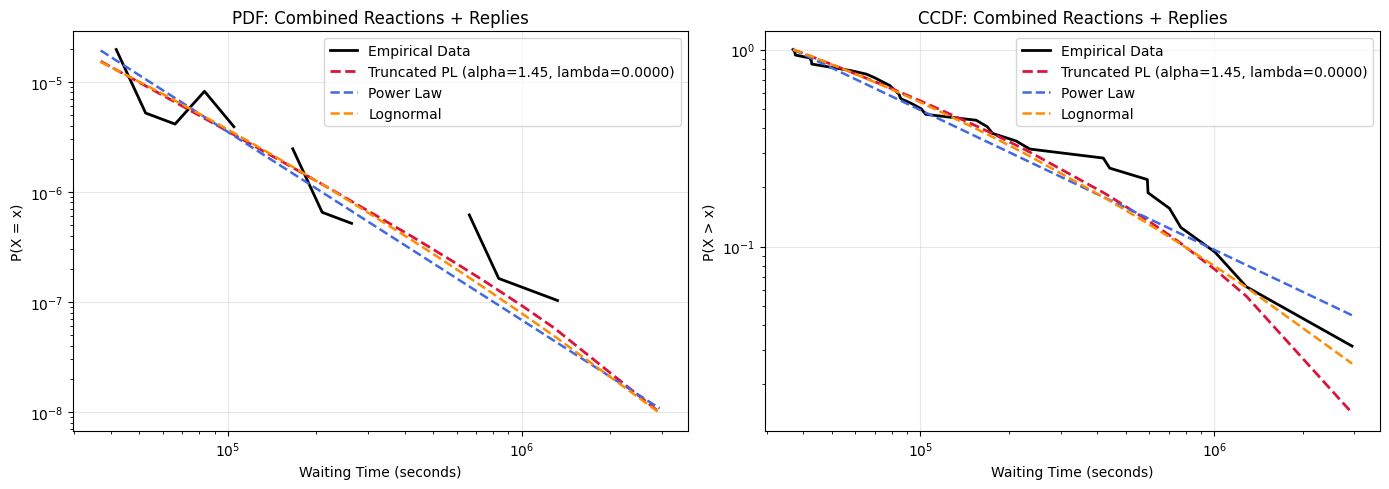

In [37]:
# Do power-law fitting on the combined waiting times
fit_combined = fit_tpl_report(combined_wt, "Combined Reactions + Replies", discrete=True)
    


### Informative links

In [38]:
### Get the message ids for the informative links.
# Work on copies to avoid mutating original dataframes
inf = informative_messages.copy()
full = df.copy()

# 1) Normalize sender_id type
inf["sender_id"] = pd.to_numeric(inf["sender_id"], errors="coerce").astype("Int64")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
inf["date_dt"] = pd.to_datetime(inf["date"], utc=True, errors="coerce")
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")

# 3) Keep only the fields needed to recover the original message id
#    df does not have a `links` column, so we only merge on columns that exist there.
full_lookup = full[["id", "sender_id", "date_dt", "topic_name"]].drop_duplicates().copy()

# 4) Exact match on sender_id + date
matches = inf.merge(
    full_lookup,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_misinfo", "_df")
)

# 5) Split matched vs unmatched rows
found_inf= matches[matches["id"].notna()].copy()
not_found_inf = matches[matches["id"].isna()].copy()

print("Found:", len(found_inf))
print("Not found:", len(not_found_inf))

# Preview the rows where we recovered the original message id
preview_cols = [col for col in ["id", "date_dt", "sender_id", "links", "topic_name"] if col in found_inf.columns]
found_inf[preview_cols].head()

Found: 1954
Not found: 7


,id,date_dt,sender_id,links,topic_name
0,47.0,2024-10-30 15:00:42+00:00,1110241832,https://www.instagram.com/victimas_dana_vlc/pr...,Discusión general
1,50.0,2024-10-30 19:15:18+00:00,1110241832,https://www.google.com/maps/d/viewer?mid=1WbP4...,Discusión general
2,56.0,2024-10-30 19:58:22+00:00,1110241832,https://g.co/kgs/y7dLSiz,Discusión general
3,57.0,2024-10-30 19:59:30+00:00,1110241832,https://g.co/kgs/q6e1mmU,Discusión general
4,58.0,2024-10-30 20:00:34+00:00,1110241832,https://g.co/kgs/VDFK7XY,Discusión general


In [39]:
# Retrieve replies to the informative messages on the same topic, and analyze waiting times
inf_ids = pd.to_numeric(found_inf["id"], errors="coerce").dropna().astype("Int64").unique()
print(f"Unique informative message ids found: {len(inf_ids)}")

# Match replies whose reply_to_msg_id points to one of those informative ids
full_reply_ids = pd.to_numeric(full["reply_to_msg_id"], errors="coerce").astype("Int64")
full_replies = full[full_reply_ids.isin(inf_ids)].copy()
print(f"Number of messages that are replies to found informative messages: {len(full_replies)}")

full_replies[["id", "reply_to_msg_id", "date", "topic_name"]].head()

Unique informative message ids found: 1530
Number of messages that are replies to found informative messages: 229


,id,reply_to_msg_id,date,topic_name
4,7,4.0,2024-10-30 12:46:02+00:00,Discusión general
58,67,50.0,2024-10-30 20:32:07+00:00,Discusión general
1075,2259,2254.0,2024-11-01 09:01:10+00:00,Bienvenid@s a la Red de Voluntari@s (leed prim...
1882,6918,6906.0,2024-11-01 21:54:27+00:00,Investigación Ciudadana: Responsabilidades Pol...
1899,7008,6969.0,2024-11-01 22:07:17+00:00,Investigación Ciudadana: Responsabilidades Pol...


In [40]:
# Get reactions for the informative messages
inf_messages = full[full["id"].isin(inf_ids)].copy()
inf_reactions = inf_messages["reactions"] 
# Drop reactions that are NaN or empty lists
inf_reactions = inf_reactions[inf_reactions.notna() & (inf_reactions.apply(lambda x: isinstance(x, list) and len(x) > 0))]
print(f"Number of informative messages with reactions: {len(inf_reactions)}")
inf_reactions.head()

Number of informative messages with reactions: 286


1       [{'user_id': 5887977931, 'username': '', 'disp...
163     [{'user_id': 727942134, 'username': 'saludconf...
835     [{'user_id': 6313382472, 'username': 'Marietat...
898     [{'user_id': 1416201548, 'username': 'Hijadela...
1357    [{'user_id': 1522647708, 'username': 'Ari_1234...
Name: reactions, dtype: object

In [41]:
# Compute waiting time for ALL reactions to each informative message


# Keep informative messages that have non-empty reactions
inf_messages = full[full["id"].isin(inf_ids)].copy()
inf_messages = inf_messages[inf_messages["reactions"].notna()]
inf_messages = inf_messages[inf_messages["reactions"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

print(f"Messages with reactions: {len(inf_messages)}")

# Detect available keys inside reaction objects
reaction_keys = set()
for rlist in inf_messages["reactions"]:
    for item in rlist:
        if isinstance(item, dict):
            reaction_keys.update(item.keys())

print("Reaction keys found:", sorted(reaction_keys))

time_keys = ["date", "date_dt", "timestamp", "time", "reacted_at"]
available_time_keys = [k for k in time_keys if k in reaction_keys]
if not available_time_keys:
    print("No reaction timestamp key found in `reactions` objects.")
    print("Cannot compute reaction waiting times without a timestamp per reaction.")
else:
    tkey = available_time_keys[0]
    print(f"Using reaction timestamp key: {tkey}")

    # Normalize message timestamp once
    inf_messages["msg_date_dt"] = pd.to_datetime(inf_messages["date"], utc=True, errors="coerce")

    # Build one row per reaction event
    reaction_rows = []
    for _, row in inf_messages.iterrows():
        msg_id = row["id"]
        msg_dt = row["msg_date_dt"]
        for item in row["reactions"]:
            if not isinstance(item, dict):
                continue

            reaction_dt = pd.to_datetime(item.get(tkey), utc=True, errors="coerce")
            if pd.isna(msg_dt) or pd.isna(reaction_dt):
                continue

            wait_sec = (reaction_dt - msg_dt).total_seconds()
            if wait_sec < 0:
                # Guard against malformed timestamps
                continue

            reaction_rows.append({
                "message_id": msg_id,
                "message_date": msg_dt,
                "reaction_date": reaction_dt,
                "reaction": item.get("reaction"),
                "reactor_user_id": item.get("user_id"),
                "reactor_username": item.get("username"),
                "wait_seconds": wait_sec
            })

    reactions_waiting_df = pd.DataFrame(reaction_rows).sort_values(["message_id", "reaction_date"]).reset_index(drop=True)
    all_reaction_waiting_times = reactions_waiting_df["wait_seconds"].to_numpy(dtype=float)

    print(f"Total reaction events with waiting time: {len(reactions_waiting_df)}")
    if len(reactions_waiting_df) > 0:
        print(
            "Wait time stats (sec) -> ",
            f"min={reactions_waiting_df['wait_seconds'].min():.1f}, ",
            f"median={reactions_waiting_df['wait_seconds'].median():.1f}, ",
            f"max={reactions_waiting_df['wait_seconds'].max():.1f}",
            sep=""
        )
        display(reactions_waiting_df.head(10))

Messages with reactions: 286
Reaction keys found: ['date', 'display_name', 'reaction', 'user_id', 'username']
Using reaction timestamp key: date
Total reaction events with waiting time: 487
Wait time stats (sec) -> min=5.0, median=35643.0, max=31886934.0


,message_id,message_date,reaction_date,reaction,reactor_user_id,reactor_username,wait_seconds
0,4,2024-10-30 12:40:50+00:00,2024-11-01 18:21:39+00:00,😢,1799229037,,193249.0
1,4,2024-10-30 12:40:50+00:00,2024-11-01 21:17:08+00:00,😢,1752625047,,203778.0
2,4,2024-10-30 12:40:50+00:00,2024-11-02 07:24:34+00:00,😢,7302637842,,240224.0
3,4,2024-10-30 12:40:50+00:00,2024-11-02 15:02:21+00:00,😢,1072460858,MaykasileX,267691.0
4,4,2024-10-30 12:40:50+00:00,2024-11-02 17:17:52+00:00,😢,636805551,Acercantabria,275822.0
5,4,2024-10-30 12:40:50+00:00,2024-11-02 17:42:11+00:00,😢,828945488,CarmenCid_Diaz,277281.0
6,4,2024-10-30 12:40:50+00:00,2024-11-03 07:56:52+00:00,😢,1141298637,,328562.0
7,4,2024-10-30 12:40:50+00:00,2024-11-03 11:00:29+00:00,😢,6457771919,Perulo11,339579.0
8,4,2024-10-30 12:40:50+00:00,2024-11-03 15:09:05+00:00,😢,100495231,Nuria_BdlB,354495.0
9,4,2024-10-30 12:40:50+00:00,2024-11-03 17:40:01+00:00,😢,5145323674,ZR3145,363551.0


In [42]:
# Get waiting times for reactions that occurred within 60 minutes of the original message
reactions_wt = reactions_waiting_df["wait_seconds"] 
# Get waiting times from replies as well
replies_wt = full_replies["date_dt"] - full_replies["reply_to_msg_id"].map(full.set_index("id")["date_dt"])
replies_wt = replies_wt.dt.total_seconds()
# Combine
combined_wt = pd.concat([reactions_wt, replies_wt], ignore_index=True)
combined_wt = combined_wt[combined_wt >= 0]  # Keep only non-negative waiting times
print(f"Combined reactions + replies with non-negative waiting times: {len(combined_wt)}")
print(
    "Combined wait time stats (sec) -> ",
    f"min={combined_wt.min():.1f}, ",
    f"median={combined_wt.median():.1f}, ",
    f"max={combined_wt.max():.1f}",
    sep=""
)

Combined reactions + replies with non-negative waiting times: 716
Combined wait time stats (sec) -> min=0.0, median=14079.0, max=31886934.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Combined Reactions + Replies
alpha: 1.9206
lambda: 0.000000
xmin: 2090228.0000
sigma: nan
Data points above xmin: 43 / 714 (6.02%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.9297, p = 0.2734
  No significant difference

Truncated PL vs Lognormal:
  R = 1.2529, p = 0.2102
  No significant difference

Truncated PL vs Exponential:
  R = 1.8876, p = 0.0591
  No significant difference

KS distance (truncated power law): 0.0841
KS p-value (tail): 0.895973


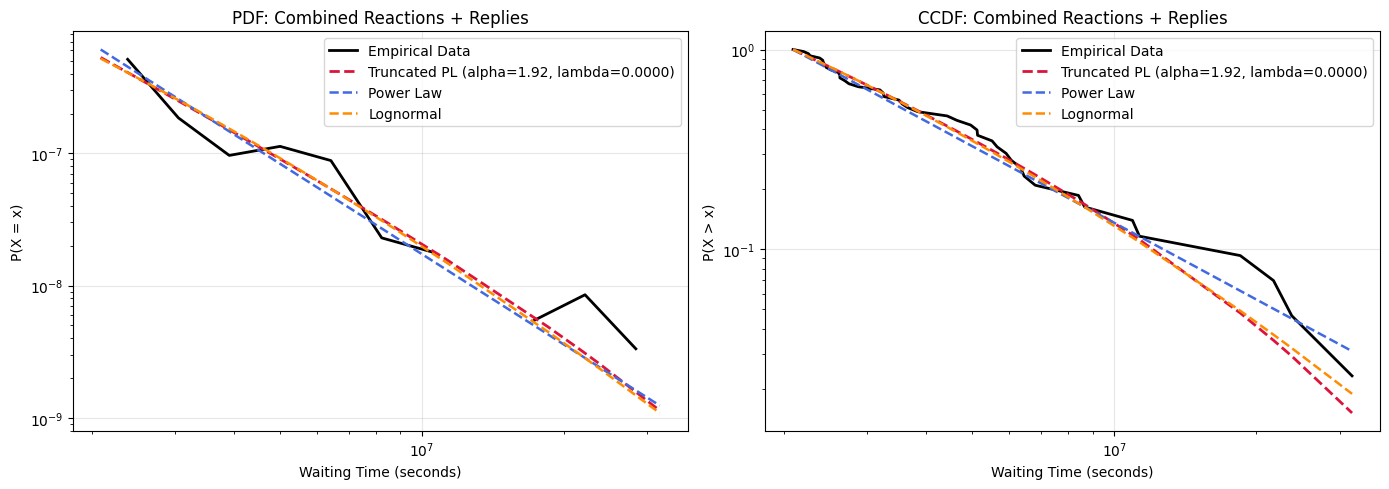

In [43]:
# Do power-law fitting on the combined waiting times
fit_combined = fit_tpl_report(combined_wt, "Combined Reactions + Replies", discrete=True)
    
